In [9]:
import requests
import pandas as pd
from typing import Final
from blocksnet.enums import LandUse


In [10]:
from urbanomy.methods.investment_potential import prepare_investment_input
scenario_blocks = pd.read_pickle('../data/blocks_with_price_final.pickle').to_crs(32636)


scenario_blocks = scenario_blocks.loc[scenario_blocks['is_project'] == True].copy()

potential_df = pd.read_csv("../data/land_use_potentials.csv")

investment_input = prepare_investment_input(
    gdf = scenario_blocks,
    project_potential = potential_df,
)

investment_input.head()


2025-12-08 15:22:03.216 | WARNING  | urbanomy.utils.investment_input:_prepare_with_base:347 - prepare_investment_input: у 3 из 70 кварталов нет land-use после нормализации; они остаются в наборе и будут обработаны на следующем этапе.


,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.AGRICULTURE,1.889022e+08,1.040179e+08,202399.732193,0.000000,12550.410318,12550.410318,0.918180,3.0
1,LandUse.BUSINESS,2.096246e+08,1.035707e+08,201529.493481,0.000000,40777.536145,40777.536145,0.938081,2.0
2,LandUse.TRANSPORT,1.502461e+08,8.462455e+07,164663.859830,0.000000,24985.649917,24985.649917,0.891381,4.0
3,LandUse.RESIDENTIAL,4.697694e+08,8.303549e+07,161571.832511,29356.900162,43211.792478,72568.692640,0.934862,0.0
4,None,4.721626e+04,3.494857e+03,16.489152,0.000000,1.306345,1.306345,1.000000,0.0


## Инвевстиционная привлекательность

In [11]:
from blocksnet.enums import LandUse

benchmarks_demo = {
    LandUse.RESIDENTIAL: {
        "cost_build": 45_000,
        "price_sale": 140_000,
        "construction_years": 3,
        "sale_years": 4,
        "opex_rate": 800,
    },
    LandUse.BUSINESS: {
        "cost_build": 55_000,
        "rent_annual": 25_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_300,
    },
    LandUse.RECREATION: {
        "cost_build": 20_000,
        "rent_annual": 7_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_000,
    },
    LandUse.SPECIAL: {
        "cost_build": 35_000,
        "rent_annual": 11_000,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 1_500,
    },
    LandUse.INDUSTRIAL: {
        "cost_build": 38_000,
        "rent_annual": 14_800,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 700,
    },
    LandUse.AGRICULTURE: {
        "cost_build": 25_000,
        "rent_annual": 6_500,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 300,
    },
    LandUse.TRANSPORT: {
        "cost_build": 18_000,
        "rent_annual": 8_200,
        "rent_years": 15,
        "construction_years": 3,
        "opex_rate": 600,
    },
}




In [12]:
investment_input

,land_use,land_value,land_value_before,site_area,living_area,non_living_area,build_floor_area,share,spatial_potential
0,LandUse.AGRICULTURE,1.889022e+08,1.040179e+08,202399.732193,0.000000,12550.410318,12550.410318,0.918180,3.0
1,LandUse.BUSINESS,2.096246e+08,1.035707e+08,201529.493481,0.000000,40777.536145,40777.536145,0.938081,2.0
2,LandUse.TRANSPORT,1.502461e+08,8.462455e+07,164663.859830,0.000000,24985.649917,24985.649917,0.891381,4.0
3,LandUse.RESIDENTIAL,4.697694e+08,8.303549e+07,161571.832511,29356.900162,43211.792478,72568.692640,0.934862,0.0
4,None,4.721626e+04,3.494857e+03,16.489152,0.000000,1.306345,1.306345,1.000000,0.0
...,...,...,...,...,...,...,...,...,...
65,LandUse.BUSINESS,1.332765e+06,1.453715e+06,606.983089,0.000000,203.637762,203.637762,1.000000,2.0
66,LandUse.AGRICULTURE,1.075884e+04,4.800058e+04,2.674417,0.000000,0.000000,0.000000,1.000000,3.0
67,LandUse.TRANSPORT,4.415762e+06,2.213805e+06,4307.658859,0.000000,688.576001,688.576001,0.910136,4.0
68,LandUse.BUSINESS,1.888382e+04,2.220956e+04,61.628241,0.000000,13.487254,13.487254,1.000000,2.0


In [6]:
from urbanomy.methods.investment_potential import InvestmentAttractivenessAnalyzer

an = InvestmentAttractivenessAnalyzer(benchmarks=benchmarks_demo)
summary = an.calculate_investment_metrics(investment_input, discount_rate=0.18)
summary


2025-12-08 15:21:51.396 | WARNING  | urbanomy.methods.investment_potential.investment_metrics:calculate_investment_metrics:562 - calculate_investment_metrics: 3 из 70 кварталов без land-use; пропускаем их в расчётах, но оставляем в итоговом отчёте.


Project totals:
 • Land area:          5,759,857.12
 • Built area:         1,426,481.21
 • Land value:         6,218,422,381.53
 • Construction cost:  54,162,061,333.49
 • Investment need:    60,380,483,715.02
 • Spatial potential:  3.13
 • Project NPV:        15,524,251,465.38
 • Project IRR:        0.24
 • Project ROI:        7.59
 • Project PP (yrs):   7.88
 • Project EI:         76.45
 • Project INV score:  77.21


,land_use,land_area,land_value_before,built_area,land_value,construction_cost,investment_need,NPV,IRR,ROI,PP_years,EI,spatial_potential,INV
0,LandUse.AGRICULTURE,202399.73,1.040179e+08,12550.41,1.889022e+08,3.137603e+08,5.026624e+08,-1.971050e+08,0.09,2.92,NaN,0.00,3.0,31.07
1,LandUse.BUSINESS,201529.49,1.035707e+08,40777.54,2.096246e+08,2.242764e+09,2.452389e+09,1.175440e+09,0.27,12.59,8.41,87.85,2.0,72.17
2,LandUse.TRANSPORT,164663.86,8.462455e+07,24985.65,1.502461e+08,4.497417e+08,5.999878e+08,7.812487e+07,0.21,7.38,12.73,29.17,4.0,58.51
3,LandUse.RESIDENTIAL,161571.83,8.303549e+07,72568.69,4.697694e+08,3.265591e+09,3.735361e+09,1.532286e+09,0.32,4.97,5.44,100.00,0.0,58.57
4,None,NaN,3.494860e+03,NaN,4.721626e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,LandUse.BUSINESS,606.98,1.453714e+06,203.64,1.332765e+06,1.120008e+07,1.253284e+07,6.736753e+06,0.28,12.82,8.06,43.35,2.0,46.10
66,LandUse.AGRICULTURE,2.67,4.800058e+04,NaN,1.075884e+04,NaN,1.075884e+04,-7.305800e+03,0.16,6.18,NaN,0.00,3.0,31.07
67,LandUse.TRANSPORT,4307.66,2.213805e+06,688.58,4.415762e+06,1.239437e+07,1.681013e+07,2.265107e+06,0.21,7.33,12.63,11.45,4.0,48.14
68,LandUse.BUSINESS,61.63,2.220956e+04,13.49,1.888382e+04,7.417990e+05,7.606828e+05,5.155732e+05,0.31,16.16,7.36,52.77,2.0,51.62


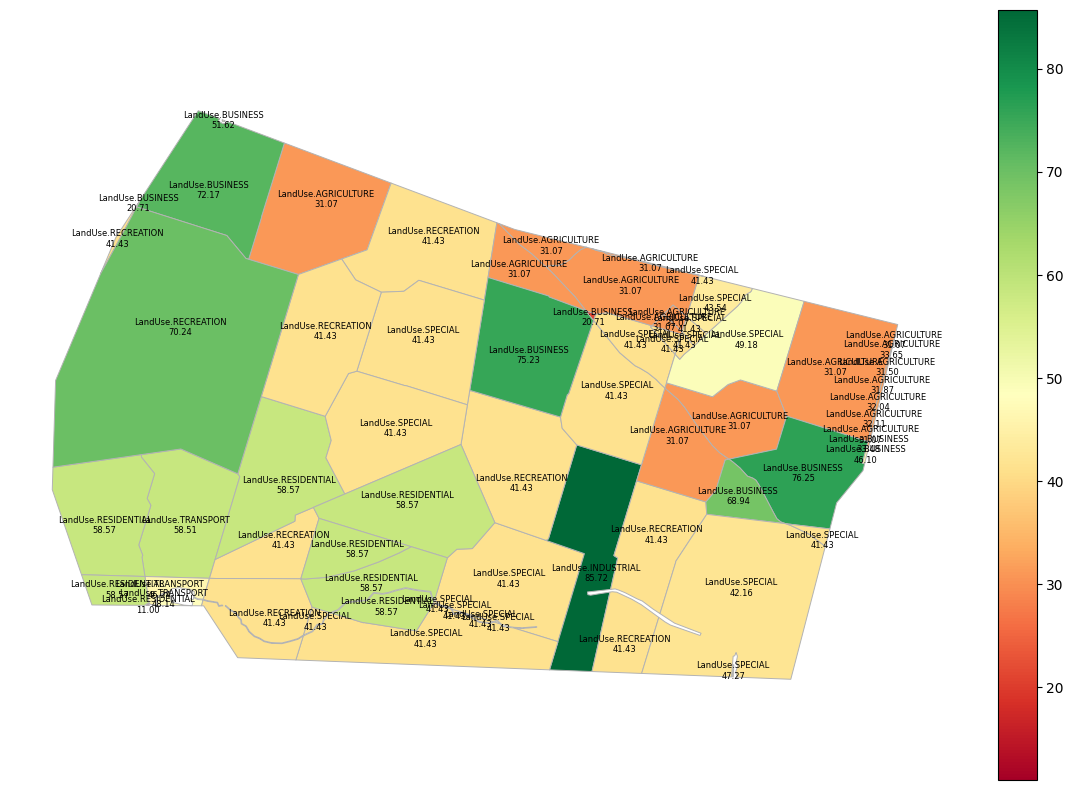

In [13]:
scn = scenario_blocks[['geometry']].join(summary)
column = 'INV'

ax = scn.plot(column=column, cmap='RdYlGn', legend=True, figsize=(15, 10), edgecolor='0.7', linewidth=0.7)
for _, row in scn.dropna(subset=[column]).iterrows():
    x, y = row.geometry.representative_point().coords[0]
    ax.text(
        x,
        y,
        f"{row.land_use}\n{row[column]:.2f}",
        ha="center",
        va="center",
        fontsize=6,
        color="black",
    )

ax.set_axis_off()

In [14]:
scn.to_file('../data/blocks_investment.geojson', driver='GeoJSON')